# Plotting XY Data

This notebook demonstrates how to plot XY coordinate data using gplately. In geology, XY data typically refers to spatial coordinates (X and Y) that represent locations in a projected coordinate system (such as UTM eastings and northings, local survey grids, or model domain coordinates).

These datasets are widely used to visualize geological features like fault traces, sample sites, well locations, or cross-section lines. Unlike global latitude–longitude data, XY coordinate data is often used for regional or local-scale geological mapping where a planar projection is appropriate.

### Setup

Let’s start by importing the required packages.

In [2]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygplates cartopy geopandas matplotlib pandas numpy` if not already installed.
import gplately
from plate_model_manager import PlateModelManager
import pygplates
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

We then extract individual layers from the model:

- Coastlines: for reconstructing ancient shorelines.

- ContinentalPolygons: for plotting continental outlines.

- COBs (Continent-Ocean Boundaries): useful for defining the transition between land and oceanic crust.

Finally, we create a `PlotTopologies object (gplot)`, which simplifies visualizing reconstructed features like plate boundaries, continents, and COBs at any geological time.

In [2]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time_ma = 100  # Ma (Million years ago)

# Define input filename (for Format 2)
input_polylines_filename = '../../data/input_polylines.txt'

### Importing XY Data 

We’ll explore two common ways to import and visualize geological point data: by defining a list of coordinates directly in the notebook and by reading polyline data from an external file.

#### Format 1: Inline Defined List

- We create a list of well-known cities (like Sydney, London, Tokyo) is created, with each city’s current latitude and longitude.

- Each city is turned into a pyGPlates point feature, so it can be reconstructed using the plate motion model.

- Each city is matched to the tectonic plate it sits on (e.g., Sydney → Australian Plate). These plate IDs are necessary to tell the model which chunk of Earth’s crust the city belongs to, so it knows how to move it back in time.

In [3]:
# --- Define XY data (longitude, latitude, city name) ---
cities = [
    {'name': 'Sydney', 'lon': 151.2093, 'lat': -33.8688},
    {'name': 'London', 'lon': -0.1278, 'lat': 51.5074},
    {'name': 'Tokyo', 'lon': 139.6917, 'lat': 35.6895},
    {'name': 'Cairo', 'lon': 31.2357, 'lat': 30.0444},
    {'name': 'Rio de Janeiro', 'lon': -43.1729, 'lat': -22.9068},
    {'name': 'New York', 'lon': -74.0060, 'lat': 40.7128}
]

# Create point features
point_features = []
for city in cities:
    point = pygplates.PointOnSphere(city['lat'], city['lon'])  # lat/lon order for pyGPlates
    feature = pygplates.Feature()
    feature.set_geometry(point)
    feature.set_name(city['name']) 
    point_features.append(feature)

#### Format 2: Local File

To illustrate how we can import XY data from a local file, we read a set of polyline data from a file. In many geological applications, coordinate data are stored as polylines i.e. continuous sets of longitude–latitude pairs that represent features such as coastlines, fault traces, or plate boundaries. The polyline data in the input file represents a global sample of major mountain ranges.

Here, we use '>' to mark breaks between segments. An example input text file (in longitude–latitude order) might look like this: 

```
>
  -79.747867  -1.444159
  -79.786712  -1.654002
  -79.872547  -2.221801
  -79.858122  -6.951201
  -78.850008  -9.359851
  -76.020448  -13.798207
>
  -75.549659  -14.315297
  -75.411320  -14.456342
  -74.335501  -15.543422
  -72.539796  -17.187214
  -71.922547  -17.773935
  -71.381735  -18.373316
  -70.979182  -18.850190
  -70.786266  -19.126329
>
  -70.571175  -19.417365
  -70.343507  -19.716224
  -70.280285  -19.858811
  -70.107565  -20.531859
  -70.059697  -22.248895
```

We first parse the file and read in a series of coordinate pairs. After defining this XY data, we loop through each polyline and:

- Create a `PolylineOnSphere` i.e. pyGPlates’ internal representation of a geographic point.

- Create a Feature i.e. a pyGPlates object that can store geometry plus metadata.

- Attach the polyline geometry and any descriptive attributes (e.g., name or type of feature).

- Add the feature to a list (`polyline_features`).

This process converts our raw coordinate lists into objects that `pyGPlates` can recognize and manipulate.

In [ ]:
# A function that creates a polyline feature from some points.
def add_polyline_feature_from_points(polyline_features, points, line_number):

    # If have no points then nothing to do.
    if not points:
        return

    # Need at least two points for a polyline.
    if len(points) >= 2:
        polyline = pygplates.PolylineOnSphere(points)
        polyline_feature = pygplates.Feature()
        polyline_feature.set_geometry(polyline)
        polyline_features.append(polyline_feature)
    else:   # If only one point then warning.
        print('Line %d: Ignoring polyline - polyline has only one point.' % (line_number-1))
    # Clear points list for next feature.
    del points[:]


# Parse the input polylines text file containing groups of lon/lat points per line.
polyline_features = []
polyline_points = []
with open(input_polylines_filename, 'r') as input_polylines_file:
    for line_number, line in enumerate(input_polylines_file):

        # Make line number 1-based instead of 0-based.
        line_number = line_number + 1

        # See if line begins with '>'.
        # This is was separates groups of points into polylines.
        if line.strip().startswith('>'):

            # Generate the previous polyline feature.
            add_polyline_feature_from_points(polyline_features, polyline_points, line_number)
            continue

        line_string_list = line.split()

        # Need at least two strings per line (for latitude and longitude).
        if len(line_string_list) < 2:
            print('Line %d: Ignoring point - line does not have at least two white-space separated strings.' % line_number)
            continue

        # Attempt to convert each string into a floating-point number.
        try:
            # Use GMT (lon/lat) order.
            lon = float(line_string_list[0])
            lat = float(line_string_list[1])
        except ValueError:
            print('Line %d: Ignoring point - cannot read lon/lat values.' % line_number)
            continue

        # Create a pyGPlates point from the latitude and longitude
        # and add it to our list of points.
        polyline_points.append(pygplates.PointOnSphere(lat, lon))

    # If we have any points leftover then generate the last polyline feature.
    add_polyline_feature_from_points(polyline_features, polyline_points, line_number)

### Assigning Plate IDs!

Now that we’ve defined both our point features (Format 1) and polyline features (Format 2), the next step is to assign plate IDs to each geometry. This links every point or line to the tectonic plate it belongs to, allowing `gplately` to move them correctly through time.

Here’s how the process works:

- Each feature, whether a city point or a polyline segment, is compared against the static plate polygons, which define the present-day extent of tectonic plates.

- Using the rotation model, `pyGPlates` determines which plate each feature sits on and how it moves through geological time.

- The `properties_to_copy` argument specifies which metadata to attach to each feature. In this case, we copy the reconstruction plate ID and the valid time period for each feature.

This process is applied separately for both formats:

In [5]:
# Assign plate IDs to the points (format 1)
assigned_features = pygplates.partition_into_plates(
    static_polygons_filename,
    rotation_model,
    point_features,
    properties_to_copy=[
        pygplates.PartitionProperty.reconstruction_plate_id,
        pygplates.PartitionProperty.valid_time_period
    ]
)

# Assign plate IDs to the polylines (format 2)
assigned_polyline_features = pygplates.partition_into_plates(
    static_polygons_filename,
    rotation_model,
    polyline_features,
    properties_to_copy = [
        pygplates.PartitionProperty.reconstruction_plate_id,
        pygplates.PartitionProperty.valid_time_period])

### Plotting

In this section, we use `Cartopy` to visualize our geological data on global maps, alongside [`PlotTopologies` object](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html) for plotting coastlines and reconstructed features.

We’ll create two separate plots:

- One showing the point features (e.g. cities or sampling sites), and

- Another showing the polyline features (e.g. coastlines, fault traces, or plate boundaries).

- Both are displayed at present day (0 Ma).

#### Plot 1 – Points (Format 1)

This plot shows modern-day point features over present-day coastlines. Each point (for example, a city) is plotted and labeled with its name.

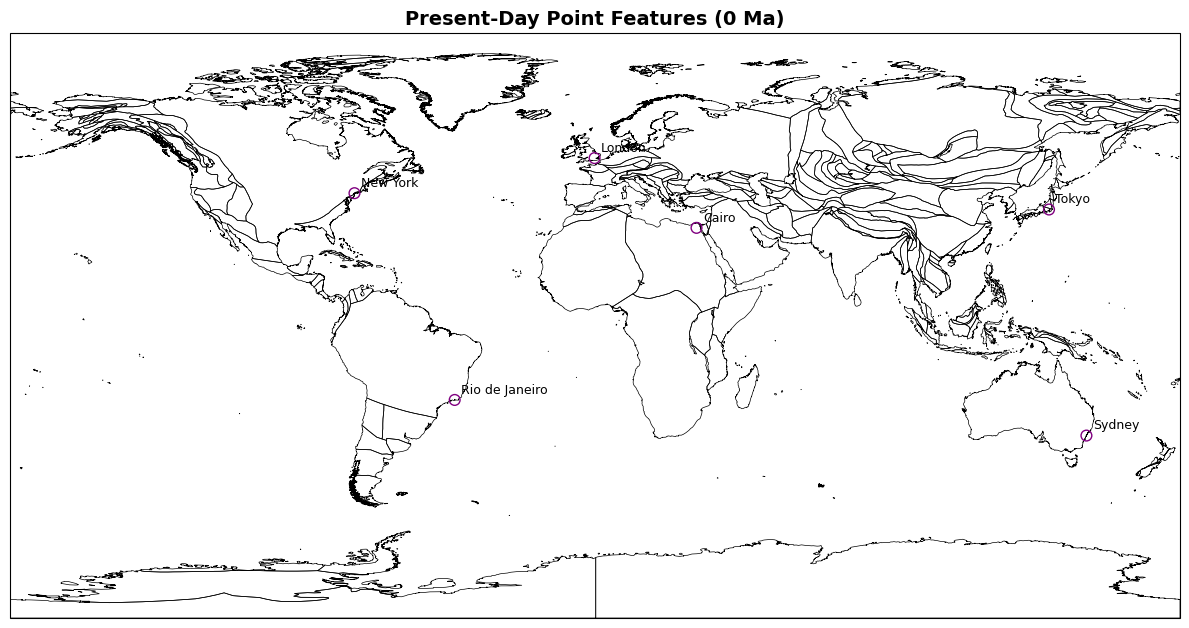

In [6]:
# --- Plot settings ---
figsize = (12, 8)
dot_size = 60
dot_color = 'purple'

# --- PLOT 1: Present-Day Points (0 Ma) ---
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# Get and plot present-day coastlines
present_coastlines = model.reconstruct(coastlines, to_time=0)
gplot.plot_feature(ax, present_coastlines, color='black', linewidth=0.5)

# Plot assigned point features
assigned_collection = pygplates.FeatureCollection(assigned_features)
gplot.plot_feature(ax, assigned_collection, color=dot_color, markersize=dot_size)

# Add labels for points (e.g., cities)
for feature in assigned_features:
    geometry = feature.get_geometry()
    lat, lon = geometry.to_lat_lon()
    name = feature.get_name()
    ax.text(lon + 2, lat + 2, name, fontsize=9, transform=ccrs.PlateCarree())

ax.set_title("Present-Day Point Features (0 Ma)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Plot 2 – Polylines (Format 2)

This plot displays present-day polyline features, such as coastlines or tectonic boundaries. Each line is reconstructed and drawn over the base map for comparison.

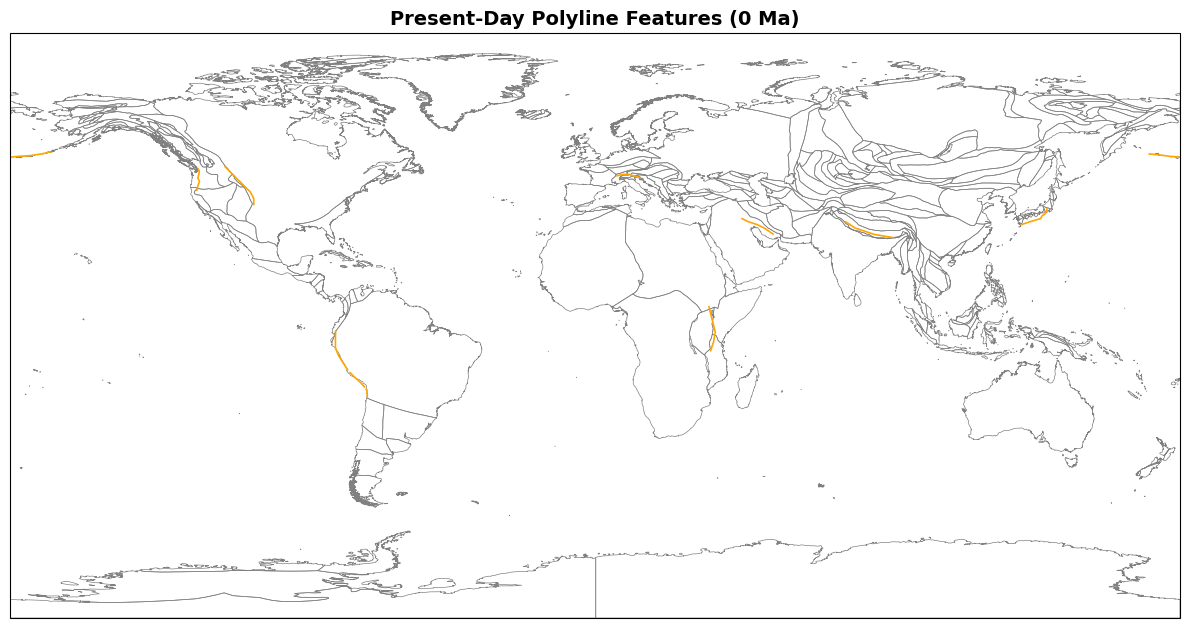

In [7]:
# --- PLOT 2: Present-Day Polylines (0 Ma) ---
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# Get and plot present-day coastlines
present_coastlines = model.reconstruct(coastlines, to_time=0)
gplot.plot_feature(ax, present_coastlines, color='grey', linewidth=0.5)

# Plot assigned polyline features
assigned_polyline_collection = pygplates.FeatureCollection(assigned_polyline_features)
gplot.plot_feature(ax, assigned_polyline_collection, color='orange', linewidth=1.2)

ax.set_title("Present-Day Polyline Features (0 Ma)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Reconstructing & Plotting

This code creates the same type of map, but "rewinds" Earth back to how it looked `time_ma` million years ago, moving both the geological features and the fossil (point) locations back through time. What's happening step by step:

- Set up the same canvas: we use the same projection and global grid so the reconstructed map lines up with the present-day plot for easy comparison.

- Set the time to 100 Ma: `time_ma = 100` and `model.reconstruct(..., to_time=time_ma)` tell `GPlately` to reconstruct Earth to that ancient time. (This is the key difference.)

- Draw Earth's ancient features: the coastlines (and any other topologies) are reconstructed and plotted at `time_ma`.

- Plot the reconstructed fossil locations (points): the points are reconstructed with the same rotation model and plotted where they would have been at `time_ma`.

- Plot the reconstructed polylines (lines): the polyline geometries (coastlines, fault traces, plate boundaries, etc.) are also reconstructed and drawn in the same figure so you can compare positions and relationships at `time_ma`.

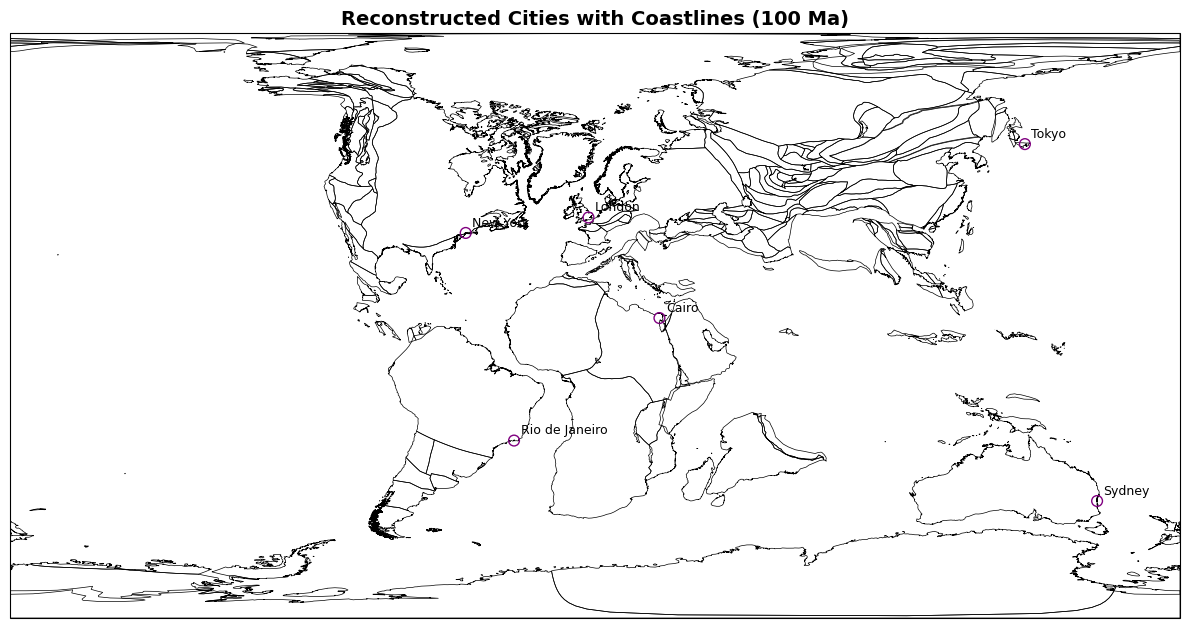

In [8]:
# --- PLOT 3: Reconstructed points to specified time ---
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# Get and plot reconstructed coastlines
reconstructed_coastlines = model.reconstruct(coastlines, to_time=time_ma)
gplot.plot_feature(ax, reconstructed_coastlines, color='black', linewidth=0.5)

# Get and plot reconstructed cities
reconstructed_cities = model.reconstruct(assigned_collection, to_time=time_ma)
gplot.plot_feature(ax, reconstructed_cities, color=dot_color, markersize=dot_size)

# Add city labels
for feature in reconstructed_cities:
    geometry = feature.get_reconstructed_geometry()
    if geometry:
        lat, lon = geometry.to_lat_lon()
        name = feature.get_feature().get_name()
        ax.text(lon + 2, lat + 2, name, fontsize=9, transform=ccrs.PlateCarree())

ax.set_title(f"Reconstructed Cities with Coastlines ({time_ma} Ma)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

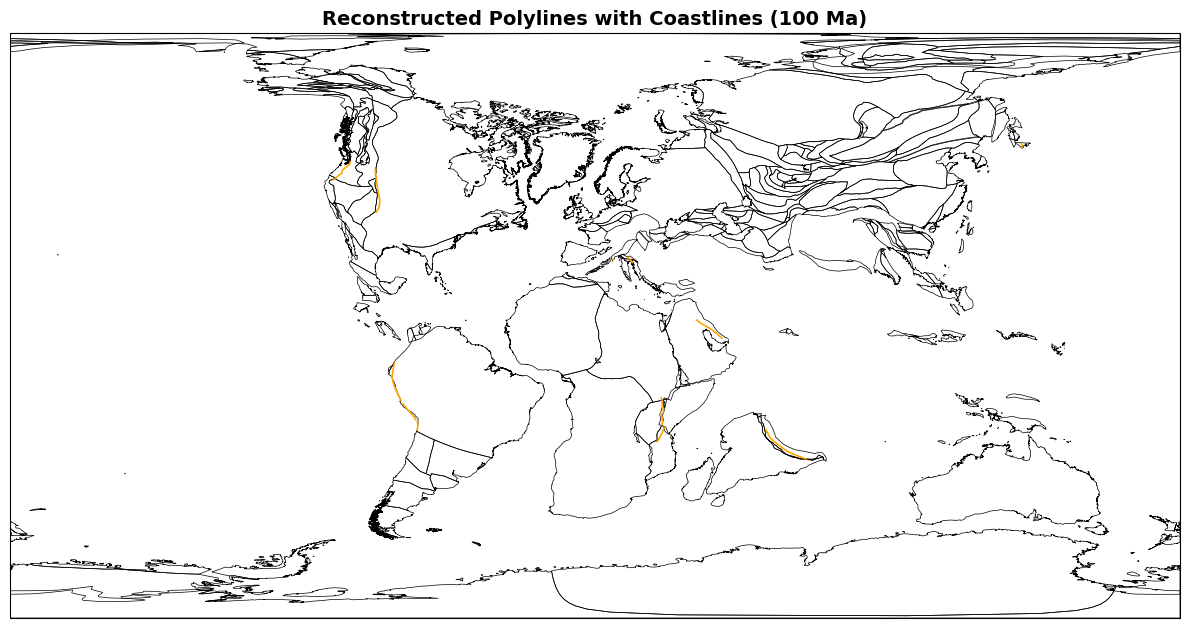

In [ ]:
# --- PLOT 4: Reconstructed polylines to specified time ---
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()

# Get and plot reconstructed coastlines
reconstructed_coastlines = model.reconstruct(coastlines, to_time=time_ma)
gplot.plot_feature(ax, reconstructed_coastlines, color='black', linewidth=0.5)

# Get and plot reconstructed polylines
reconstructed_polylines = model.reconstruct(assigned_polyline_collection, to_time=time_ma)
gplot.plot_feature(ax, reconstructed_polylines, color='orange', linewidth=1.2)

ax.set_title(f"Reconstructed Polylines with Coastlines ({time_ma} Ma)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()